<a href="https://colab.research.google.com/github/ShajeeaMinnath/Digit-Recognition-ML/blob/feature%2Feda/eda_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 46.9 MB/s eta 0:00:00
Loading MNIST...


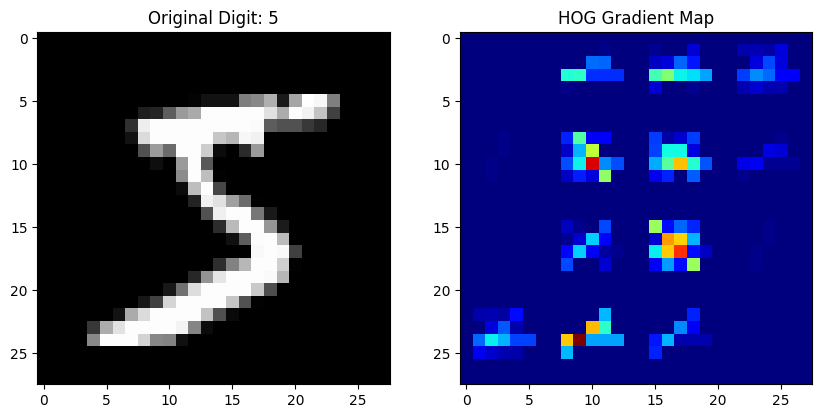

In [2]:
!pip install mahotas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from skimage.feature import hog
import mahotas

# 1. Load MNIST Data
print("Loading MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X.astype('float32')
y = y.astype('int')

# 2. Feature Extraction Functions
def extract_features(image):
    img_2d = image.reshape((28, 28))

    # Raw Pixels (Normalized)
    raw_pixels = image / 255.0

    # HOG Features (Captures stroke direction)
    hog_feats = hog(img_2d, orientations=9, pixels_per_cell=(7, 7),
                    cells_per_block=(2, 2), visualize=False)

    # Zernike Moments (Shape descriptors)
    zernike_feats = mahotas.features.zernike_moments(img_2d, radius=21, degree=8)

    return np.hstack([raw_pixels, hog_feats, zernike_feats])

# 3. Visualizing HOG (For EDA Stage)
sample_idx = 0
sample_img = X[sample_idx].reshape(28, 28)
fd, hog_viz = hog(sample_img, orientations=9, pixels_per_cell=(7, 7),
                  cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(sample_img, cmap='gray')
ax1.set_title(f'Original Digit: {y[sample_idx]}')
ax2.imshow(hog_viz, cmap='jet')
ax2.set_title('HOG Gradient Map')
plt.show()